In [ ]:
import numpy as np
import pandas as pd
import re
import collections
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.datasets import fetch_20newsgroups

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model, Input
from keras.preprocessing.sequence import pad_sequences
from keras.models import load_model
from keras.utils import to_categorical
from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import zipfile
import os
import math

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'NumPy      {np.__version__}')

TensorFlow 2.20.0
NumPy      2.0.2


# 1. Preprocesamiento de datos

# 1.1. Inspección de los datos

El primer paso a realizar dentro de un entrenamiento e implementación de un modelo de Red Neuronal es extraer aquellos datos que se van a emplear dentro del entrenamiento del modelo.


In [ ]:
df = pd.read_csv("news_dataset.csv", quotechar='"')

El dataset importado dentro de esta práctica consta de un conjunto de textos que están relacionados con noticias. Por lo tanto, podemos asumir que nuestro dataset tiene la naturaleza de un dataset propio de problemas de tratado de lenguaje natural o NLP.

Para poder inspeccionar el contenido exacto que tiene nuestro conjunto de datos, mostramos al menos un grupo pequeño de noticias que nos ayude a entender de qué trata y como están escritas algunas de las noticias.

In [ ]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Una vez inspeccionado nuestro dataset, debemos de intentar comprender cual es la estructura principal de nuestro conjunto de datos. Como hemos podido observar, nuestro dataset realmente tiene 3 columnas o atributos. Para saber el alcance de nuestro conjunto de datos, investigamos cuantas filas o instancias comprende nuestro conjunto de datos.

In [ ]:
df.shape

(120000, 3)

Dado que nos enocntramos antes un problema de clasificación de texto en función de unas categorías definidas dentro del conjunto de datos.

Debido a la naturaleza del problema que buscamos resolver, puede ocurrir que este conjunto de datos padezca de un problema: desbalance de clases. Para saber si esto es así, inspeccionamos la distribución de clases dentro de nuestro dataset.

In [ ]:
df['Class Index'].value_counts()

,count
Class Index,
3,30000
4,30000
2,30000
1,30000


Visualizamos en una gráfica de barras verticales exactamente cual es la distribución de clases.

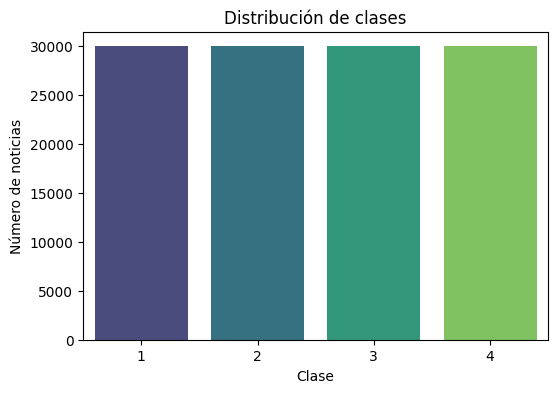

In [ ]:
def graficar_clases(df):
  """
  Summary:
    Función que grafica la distribución de las clases dentro de un dataframe

  Args:
    df: dataframe con los datos a graficar

  Returns:
    None
  """
  plt.figure(figsize=(6,4))
  sns.countplot(x='Class Index', data=df, palette='viridis')
  plt.title('Distribución de clases')
  plt.xlabel('Clase')
  plt.ylabel('Número de noticias')
  plt.show()

graficar_clases(df)

Otra de las cualidades principales de los conjuntos de datos de texto que hay que tener en cuenta para tratarlo correctamente dentro del procesamiento de la información y la implementación en una red neuronal es la longitud promedio de los documentos del corpus.

Para ello, buscamos graficar a través de un gráfico de barras expresar cual es la longitud más repetida, cuantificando a través de palabras que componen el corpus.

In [ ]:
def graficar_longitudes(df):
  """
  Summary:
    Función que grafica la distribución de las longitudes de las descripciones dentro de un dataframe

  Args:
    df: dataframe con los datos a graficar

  Returns:
    None
  """
  plt.figure(figsize=(8,4))
  sns.histplot(df['longitud'], bins=40, kde=True)
  plt.title('Distribución de longitud de descripciones (en palabras)')
  plt.xlabel('Número de palabras')
  plt.show()
  print()

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: longitud, dtype: float64


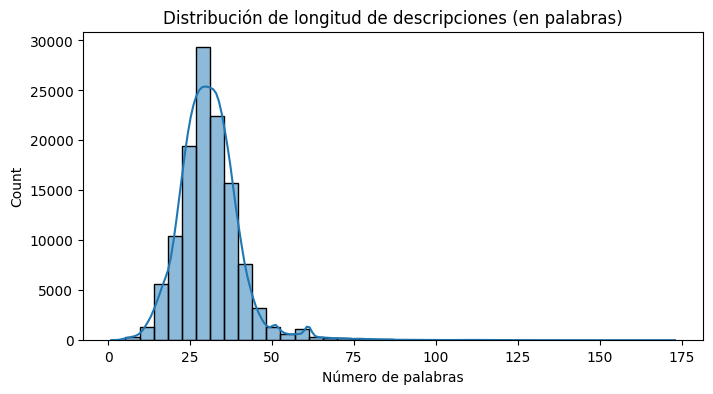

In [ ]:
df['longitud'] = df['Description'].apply(lambda x: len(str(x).split()))
print(df['longitud'].describe())
graficar_longitudes(df)

Otra de las buenas prácticas dentro del tratado de datos dentro de un corpus es inspeccionar aquellos caracteres que no aportan ningun tipo de información dentro de los documentos que componen nuestro conjunto de datos- Además, puede haber diversas expresiones o caracteres que no solo no aporten sino que ensucien el corpus, dado que sean errores propios de la extracción del conjunto de datos, como lo pueden ser etiquetas propias de lenguajes de marcas como HTML.

In [ ]:
def limpiar_texto(texto):
  """
  Summary:
    Función que limpia el texto de un dataframe de signos de puntuación, números, etc.
    Convierte el texto a minúsculas y elimina espacios en blanco al principio y al final.
    Devuelve el texto limpio.

  Args:
    texto: texto a limpiar

  Returns:
    texto: texto limpio
  """
  if not isinstance(texto, str):
      return ''
  texto = texto.lower()
  texto = re.sub(r'\[.*?\]\(.*?\)', '', texto)
  texto = re.sub(r'http\S+|www\.\S+', '', texto)
  texto = re.sub(r'<[^>]+>', ' ', texto)
  texto = texto.replace('\\', ' ')
  texto = re.sub(r'^(reuters|ap|afp)\s*-\s*', '', texto)
  texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
  texto = re.sub(r'\b\w\b', '', texto)
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

# Asignamos a nuevas columnas dentro del dataset el conjunto de textos
# limpiados de expresiones y caracteres que son inservibles
df['Description_clean'] = df['Description'].apply(limpiar_texto)
df['Title_clean'] = df['Title'].apply(limpiar_texto)
df['Texto_completo'] = df['Title_clean'] + ' ' + df['Description_clean']
df[['Title_clean', 'Description_clean', 'Texto_completo']].head(5)

,Title_clean,Description_clean,Texto_completo
0,wall st bears claw back into the black reuters,short sellers wall street dwindling band of ul...,wall st bears claw back into the black reuters...
1,carlyle looks toward commercial aerospace reuters,private investment firm carlyle group which ha...,carlyle looks toward commercial aerospace reut...
2,oil and economy cloud stocks outlook reuters,soaring crude prices plus worries about the ec...,oil and economy cloud stocks outlook reuters s...
3,iraq halts oil exports from main southern pipe...,authorities have halted oil export flows from ...,iraq halts oil exports from main southern pipe...
4,oil prices soar to all time record posing new ...,tearaway world oil prices toppling records and...,oil prices soar to all time record posing new ...


Además de limpiar de caracteres inservibles el texto de cada documento del corpus, buscamos eliminar de este el conjunto de palabras que no aporta ninguna información como tal dentro de las oraciones, como articulos, determinantes, ...


In [ ]:
stopwords = {
    'the', 'to', 'of', 'in', 'and', 'on', 'for', 'that', 'with', 'as',
    'at', 'is', 'by', 'it', 'be', 'are', 'was', 'were', 'from', 'an',
    'this', 'have', 'has', 'had', 'but', 'not', 'they', 'he', 'she',
    'we', 'you', 'his', 'her', 'their', 'its', 'our', 'or', 'will',
    'been', 'about', 'which', 'who', 'after', 'also', 'more', 'than',
    'up', 'said', 'would', 'could', 'into', 'over', 'do', 'did', 'out',
    'no', 'if', 'when', 'there', 'all', 'can', 'one', 'two', 'so', 'what',
    'lt', 'gt', 'quot', 'amp',          # restos de HTML
    'reuters', 'ap', 'afp',             # agencias
    'monday', 'tuesday', 'wednesday',   # días
    'thursday', 'friday', 'saturday', 'sunday',
    'us', 'new', 'first', 'year',       # palabras poco informativas
}

def tokenizar(texto):
    return texto.split()

tokens_completo = [tokenizar(t) for t in df['Texto_completo']]

# Filtrar stopwords de los tokens
tokens_completo = [
    [token for token in doc if token not in stopwords]
    for doc in tokens_completo
]

print('ORIGINAL:')
print((df.loc[0]['Title'] + ' ' + df.loc[0]['Description'])[:200])
print()
print('LIMPIO:')
print(df.loc[0]['Texto_completo'][:200])
print()
print('TOKENS (primeros 15):')
print(tokens_completo[0][:15])

ORIGINAL:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

LIMPIO:
wall st bears claw back into the black reuters short sellers wall street dwindling band of ultra cynics are seeing green again

TOKENS (primeros 15):
['wall', 'st', 'bears', 'claw', 'back', 'black', 'short', 'sellers', 'wall', 'street', 'dwindling', 'band', 'ultra', 'cynics', 'seeing']


Para poder inspeccionar cuales son las palabras más repetidas dentro de cada clase en el corpus, una vez este se ha limpiado, podemos mostrar una nube de palabras, o un gráfico donde se muestren en distintos tamaños cuales son las palabras más frecuentes dentro de cada clase.

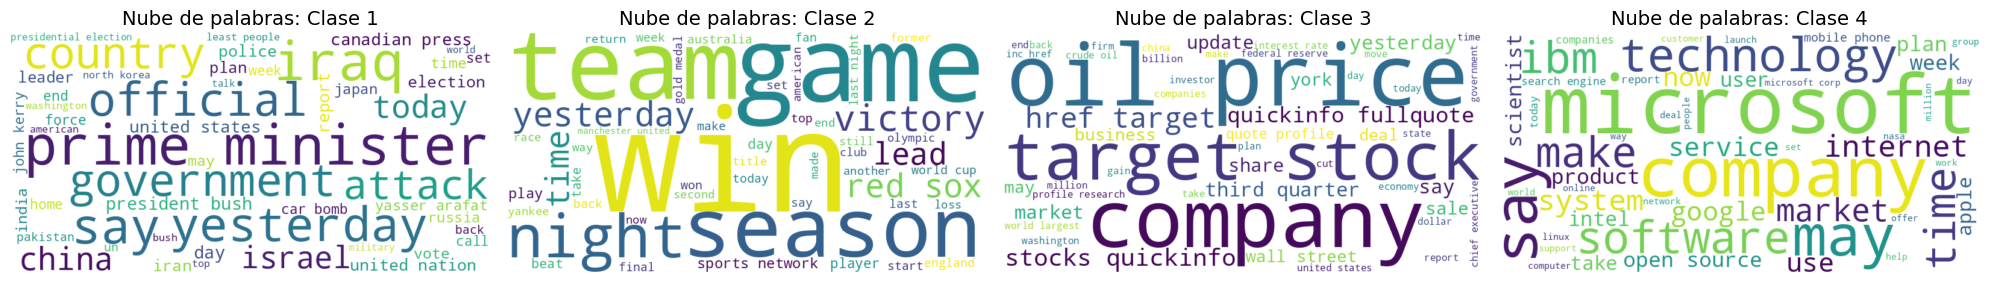

In [ ]:
def graficar_WordCloud(df):
  """
  Summary:
    Función que grafica las nubes de palabras de las clases dentro de un dataframe

  Args:
    df: dataframe con los datos a graficar

  Returns:
    None
  """

  df['Texto_procesado'] = [" ".join(tokens) for tokens in tokens_completo]

  categorias = df['Class Index'].unique()
  fig, axes = plt.subplots(1, len(categorias), figsize=(20, 5))

  for i, cat in enumerate(sorted(categorias)):
      textos_clase = " ".join(df[df['Class Index'] == cat]['Texto_procesado'])

      wordcloud = WordCloud(
          width=800,
          height=400,
          background_color='white',
          colormap='viridis',
          max_words=50
      ).generate(textos_clase)

      axes[i].imshow(wordcloud, interpolation='bilinear')
      axes[i].set_title(f'Nube de palabras: Clase {cat}', fontsize=14)
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

graficar_WordCloud(df)

Con el fin de inspeccionar en mayor detalle cuales son las palabras más frecuentes dentro de cada una de las clases que tiene nuestro corupus, buscamos visualizar a través de una gráfica de barras horizontales cuales son dichas palabras.

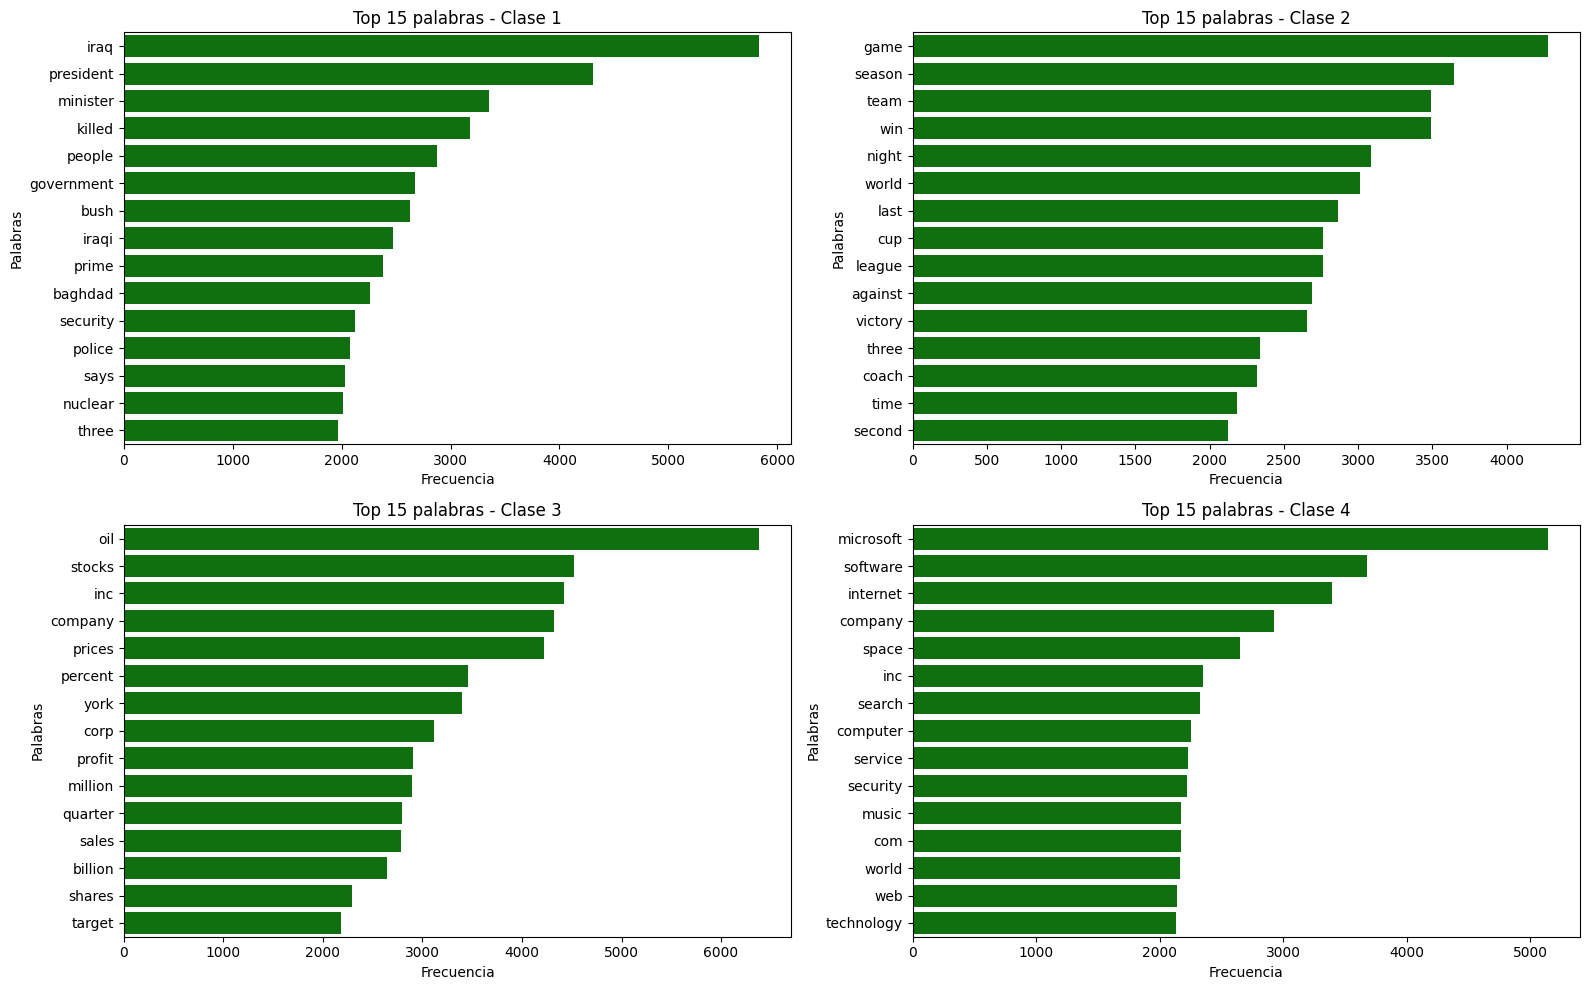

In [ ]:
def graficar_palabras_frecuentes_por_clase(df, top_n=15):
    """
    Summary:
      Grafica las palabras más frecuentes por cada clase en un grid de 2x2 mediante barras horizontales.

    Args:
      df (pandas.DataFrame): DataFrame que contiene los datos.
      top_n (int): número de palabras más frecuentes a mostrar por cada clase.

    Returns:
      None
    """
    categorias = sorted(df['Class Index'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, cat in enumerate(categorias):
        # Extraer todas las palabras de la clase
        textos = df[df['Class Index'] == cat]['Texto_procesado']
        todas_palabras = " ".join(textos).split()

        # Contar frecuencias
        contador = collections.Counter(todas_palabras)
        palabras_comunes = contador.most_common(top_n)

        if not palabras_comunes:
            continue

        palabras, frecuencias = zip(*palabras_comunes)

        # Crear gráfico de barras horizontales
        sns.barplot(x=list(frecuencias), y=list(palabras), ax=axes[i], color='green')
        axes[i].set_title(f'Top {top_n} palabras - Clase {cat}')
        axes[i].set_xlabel('Frecuencia')
        axes[i].set_ylabel('Palabras')

    plt.tight_layout()
    plt.show()

graficar_palabras_frecuentes_por_clase(df)


Una vez limpio el texto, necesitamos convertirlo en números para que el modelo pueda procesarlo.
Este proceso tiene dos pasos:

**Tokenización:** dividir cada texto en una lista de palabras individuales.
Por ejemplo: `"soaring crude prices"` → `['soaring', 'crude', 'prices']`

**Vocabulario:** construir un diccionario `palabra → ID numérico` con todas las palabras del corpus.
Solo incluimos palabras que aparecen al menos 5 veces (`MIN_FREQ=5`), descartando palabras
muy raras que no tienen suficiente contexto para aprender un buen embedding.

Para poder hacer esto, tenemos que quitar algunas palabras inservibles que van a tener influencia en la selección de tokens. Para eso vamos a crear una lista de palabras las cuales se repiten mucho como their, but, etc. Estas palabras se conocen como **stopwords** y no aportan significado semántico al texto — palabras como artículos, preposiciones, conjunciones y pronombres aparecen en cualquier tipo de noticia independientemente de su categoría, por lo que incluirlas en el vocabulario solo añade ruido al modelo. Además, eliminamos residuos de HTML (`lt`, `gt`, `quot`) y nombres de agencias de noticias (`reuters`, `ap`, `afp`) que tampoco aportan información relevante.

In [ ]:
MIN_FREQ = 5

# Contar frecuencias en el corpus
freq = collections.Counter(token for doc in tokens_completo for token in doc)

print(f'Palabras únicas (sin filtrar): {len(freq):,}')
print(f'Palabras con freq >= {MIN_FREQ}: {sum(1 for f in freq.values() if f >= MIN_FREQ):,}')
print()

# Construir vocabulario: palabra → ID
word2idx = {'<PAD>': 0, '<UNK>': 1}
for palabra, conteo in freq.most_common():
    if conteo >= MIN_FREQ:
        word2idx[palabra] = len(word2idx)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Tamaño final del vocabulario: {VOCAB_SIZE:,}')
print(f'  (incluye <PAD>=0 y <UNK>=1)')
print()
print('Top 15 palabras más frecuentes:')
for palabra, conteo in freq.most_common(15):
    print(f'  {palabra:<15} freq={conteo:>5}  ID={word2idx.get(palabra, "?")}')

Palabras únicas (sin filtrar): 61,648
Palabras con freq >= 5: 26,719

Tamaño final del vocabulario: 26,721
  (incluye <PAD>=0 y <UNK>=1)

Top 15 palabras más frecuentes:
  world           freq= 8634  ID=2
  company         freq= 7656  ID=3
  oil             freq= 7564  ID=4
  against         freq= 6899  ID=5
  inc             freq= 6853  ID=6
  last            freq= 6548  ID=7
  iraq            freq= 6335  ID=8
  york            freq= 6268  ID=9
  yesterday       freq= 6099  ID=10
  three           freq= 6034  ID=11
  president       freq= 5994  ID=12
  microsoft       freq= 5935  ID=13
  million         freq= 5812  ID=14
  game            freq= 5774  ID=15
  week            freq= 5654  ID=16


In [ ]:
def texto_a_ids(tokens_doc, vocabulario):
    """Convierte una lista de tokens en una lista de IDs enteros."""
    UNK_ID = vocabulario.get('<UNK>', 1)
    return [vocabulario.get(token, UNK_ID) for token in tokens_doc]

# Convertir todos los textos a secuencias de IDs
secuencias = [texto_a_ids(doc, word2idx) for doc in tokens_completo]

# Verificar
print('Tokens:  ', tokens_completo[0][:8])
print('IDs:     ', secuencias[0][:8])

Tokens:   ['wall', 'st', 'bears', 'claw', 'back', 'black', 'short', 'sellers']
IDs:      [339, 266, 1495, 13816, 33, 721, 627, 7775]


In [ ]:
y = df['Class Index'].values - 1
NUM_CLASSES = 4

sec_temp, secuencias_test, y_temp, y_test_raw = train_test_split(
    secuencias, y, test_size=0.1, random_state=42, stratify=y
)

sec_train, sec_val, y_tr, y_val = train_test_split(
    sec_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp
)

longitudes = [len(s) for s in sec_train]
MAX_LEN = int(np.percentile(longitudes, 90))  # cubre el 90% de los docs
MAX_LEN = min(MAX_LEN, 200)  # tope máximo para velocidad

print(f'MAX_LEN elegido: {MAX_LEN}')
print(f'  Media de tokens por documento: {np.mean(longitudes):.0f}')
print(f'  Percentil 50: {np.percentile(longitudes, 50):.0f}')
print(f'  Percentil 90: {np.percentile(longitudes, 90):.0f}')
print(f'  Máximo:       {max(longitudes)}')

X_tr  = pad_sequences(sec_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(sec_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_te  = pad_sequences(secuencias_test, maxlen=MAX_LEN, padding='post', truncating='post')

y_tr_cat  = to_categorical(y_tr,        NUM_CLASSES)
y_val_cat = to_categorical(y_val,       NUM_CLASSES)
y_te_cat  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f'\nShapes resultantes:')
print(f'  X_tr:  {X_tr.shape}   y_tr:  {y_tr_cat.shape}')
print(f'  X_val: {X_val.shape}  y_val: {y_val_cat.shape}')
print(f'  X_te:  {X_te.shape}   y_te:  {y_te_cat.shape}')

MAX_LEN elegido: 31
  Media de tokens por documento: 24
  Percentil 50: 24
  Percentil 90: 31
  Máximo:       105

Shapes resultantes:
  X_tr:  (96001, 31)   y_tr:  (96001, 4)
  X_val: (11999, 31)  y_val: (11999, 4)
  X_te:  (12000, 31)   y_te:  (12000, 4)


## 2.1. Extracción de Embeddings

Para poder realizar la construcción de un conjunto de modelos de procesamiento de lenguaje natural, independientemente de la arquitectura a seguir, se necesita de la incrustación de los *embeddings*, que son las representaciones vectoriales del texto como tal que compone el conjunto de datos o corpus.

La importación de los *embeddings* necesita de la extracción de estos datos desde una carpeta que se trae desde el primer ejercicio realizado dentro de la práctica. Para ello, importamos tanto los pesos como el vocabulario empleado desde dichas carpetas para poder asignar correctamente cada uno de los pesos a los valores numéricos extraídos del vocabulario elegido. Esto es necesario dado que el vocabulario está compuesto por un conjunto de palabras específicas, en un orden específico, y cada uno de los pesos se corresponde a un número o índice indicativo de la palabra a la que está relacionado.

Dentro del conjunto total de *embeddings* exportados del Ejercicio 1, buscamos utilizar dos en concreto, los cuales son:

* `embedding-dim312_v2`: esta incrustación nos permite observar el comportamiento de la red neuronal recurrente bajo la premisa de una ventana de contexto pequeña (tamaño de 2) y con una dimensionalidad reducida, de forma que puede servir como un buen punto de partida para poder analizar cuál es el comportamiento de nuestra red neuronal sin necesidad de emplear conjuntos de *embeddings* de dimensionalidad muy alta y ventanas de contexto más amplias.
* `embedding-dim752_v3`: tras la ejecución del primer ejercicio, este *embedding* es, de manera consistente, el que mejor métrica en la función de pérdida expone en comparación con el resto de incrustaciones potenciales resultantes del primer ejercicio. Por esto mismo, dado que esta incrustación tiene el potencial de poder usarse con una mejor base que el resto de las extraíbles del primer ejercicio, decidimos emplear esta.

In [ ]:
def extraer_embeddings(zip_path, extract_dir, npy_filename):
  """
  Función que extrae los embeddings pre-entrenados en un archivo zip y los carga en memoria.

  Args:
    zip_path (str): ruta al archivo zip que contiene los embeddings pre-entrenados
    extract_dir (str): directorio donde se extraerán los archivos del zip
    npy_filename (str): nombre del archivo numpy con los pesos a cargar

  Returns:
    numpy.ndarray: matriz de embeddings pre-entrenados
  """
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_dir)

  npy_path = os.path.join(extract_dir, npy_filename)
  return np.load(npy_path)


def importar_embeddings(vocab_size, emb_dim, emb_matrix):
  """
  Función que importa los embeddings pre-entrenados en un modelo de clasificación de texto.

  Args:
    vocab_size (int): tamaño del vocabulario
    emb_dim (int): dimensión de los embeddings
    emb_matrix (numpy.ndarray): matriz de embeddings pre-entrenados

  Returns:
    embedding_layer (keras.layers.Embedding): capa de embedding
  """
  embedding_layer = layers.Embedding(
      input_dim=vocab_size, output_dim=emb_dim,
      weights=[emb_matrix], trainable=False,
      input_length=MAX_LEN, mask_zero=True
  )

  return embedding_layer

# Directorio de extracción
extract_dir = '/content/embeddings_extracted'

# Extraer y cargar las matrices de embeddings usando la función
dim312_v2 = extraer_embeddings('/content/dim312_v2_embeddings.zip', extract_dir, 'dim312_v2_embeddings.npy')
dim752_v3 = extraer_embeddings('/content/dim752_v3_embeddings.zip', extract_dir, 'dim752_v3_embeddings.npy')

print("Archivos extraídos:", os.listdir(extract_dir))

print(f"Dimensiones de la matriz dim312_v2: {dim312_v2.shape}")
print(f"Dimensiones de la matriz dim752_v3: {dim752_v3.shape}")


Archivos extraídos: ['idx2word.pkl', 'dim752_v3.weights.h5', 'dim752_v3_embeddings.npy', 'dim312_v2_embeddings.npy', 'word2idx.pkl', 'dim752_v3_loss.npy', 'dim312_v2.weights.h5', 'dim312_v2_loss.npy', 'vocab_size.npy']
Dimensiones de la matriz dim312_v2: (26721, 312)
Dimensiones de la matriz dim752_v3: (26721, 752)


## 2.2. Construcción de modelos

Con el fin de resolver el problema de clasificación de texto, buscamos crear un conjunto de redes neuronales recurrentes que nos permitan tratar el lenguaje natural desde diferentes perspectivas.

Un modelo de una red neuronal que cumple con estas condiciones necesita de diferentes componentes:

* **Capa de Incrustación (Embedding Layer):** empleamos la función `importar_embeddings` y la matriz pre-entrenada (`emb_matrix`),haciendo la traducción de los índices numéricos de las palabras a vectores densos que contienen su significado semántico.
* **Capas Recurrentes (LSTM o GRU):** dependiendo del parámetro `arq`, el modelo utiliza celdas de Memoria a Corto y Largo Plazo (LSTM) o Unidades Recurrentes Cerradas (GRU) para procesar la secuencia de palabras y capturar su contexto temporal. Dado que el número de capas dentro de este bloque puede ser cambiante, establecemos la entrada `num_capas` para determinar cuantas capas recurrentes necesitamos:
    * **Capas intermedias (`return_sequences=True`):** si hay más de una capa recurrente, las primeras deben devolver la secuencia completa de estados ocultos (un vector por cada palabra) para que la siguiente capa recurrente tenga una secuencia temporal que procesar.
    * **Capa final (`return_sequences=False` por defecto):** la última capa recurrente resume todo el contexto de la oración en un único vector denso final que representa el significado global del texto.
* **Mecanismos de Regularización Avanzada:** para evitar el potencial sobreajuste (*overfitting*) resultante de las capas recurrentes, el modelo implementa:
    * **`SpatialDropout1D` (0.2):** aplicado entre las capas recurrentes. A diferencia del Dropout tradicional, este apaga dimensiones enteras del vector a lo largo de toda la secuencia en lugar de unidades individuales, lo que fuerza a las capas siguientes a no depender de una sola característica lingüística. El empleo de esta capa nace de la necesidad de implementar 'dropout' dentro del bloque convolucional y el no querer quitarnos la funcionalidad propia de CuDNN que nos permite entrenar de manera mucho más eficaz en GPU estas redes neuronales.
    * **Regularización L2 (0.001):** aplicada en la primera capa densa. Penaliza matemáticamente los pesos demasiado grandes, obligando al modelo a aprender patrones más suaves y generales.
    * **`Dropout` estándar (0.5):** apaga aleatoriamente el 50% de las neuronas de la capa Densa antes de la decisión final, forzando una votación más robusta.
* **Cabecera de Clasificación (Capas Densas):** una vez que el texto ha sido procesado por el núcleo recurrente, la información pasa a una capa `Dense` de 64 unidades con activación ReLU (para aprender combinaciones no lineales complejas), seguida por la capa final de salida. Esta última tiene tantas neuronas como categorías a predecir (`num_clases`) y utiliza la activación **`softmax`** para convertir los resultados en una distribución de probabilidades (ej. 80% Deportes, 15% Política, 5% Tecnología).
* **Configuración de Compilación:** por último, el modelo ensambla sus instrucciones de aprendizaje. Utiliza el optimizador **Adam** (que ajusta la tasa de aprendizaje definida por `lr`), y la función de pérdida **`categorical_crossentropy`**, que es el estándar matemático ideal para penalizar los errores en problemas de clasificación multiclase donde las etiquetas están codificadas en formato *One-Hot*.

In [ ]:
def construir_modelo(arq, emb_matrix, units, num_capas, lr, max_len, num_clases):
  """
  Función que construe un modelo de clasificación de texto.

  Args:
    arq (str): string que define que tipo de arquitectura va a seguir el modelo construido
    emb_matrix (numpy.ndarray): matriz de embeddings pre-entrenados
    units (int): número de unidades ocultas en la capa recurrente
    num_capas (int): número de capas recurrentes a apilar en el modelo
    lr (float): tasa de aprendizaje (learning rate) para el optimizador Adam
    max_len (int): longitud máxima de las secuencias de entrada
    num_clases (int): cantidad de clases a predecir en la capa de salida

  Returns:
    modelo: modelo construido y compilado
  """
  vocab_size, emb_dim = emb_matrix.shape
  print(f'vocab_size={vocab_size}, emb_dim={emb_dim}')

  # Seleccionar tipo de capa recurrente
  RecurrentLayer = layers.LSTM if arq == 'LSTM' else layers.GRU

  modelo = keras.Sequential(name=f'{arq}_{num_capas}L_lr{lr}')

  # Capa Embedding con pesos pre-entrenados usando la función dedicada
  capa_embedding = importar_embeddings(vocab_size, emb_dim, emb_matrix)
  modelo.add(capa_embedding)

  # Capas recurrentes dinámicas mediante bucle for
  for i in range(num_capas):
      # Si no es la última capa, debe retornar la secuencia completa
      if i < num_capas - 1:
          modelo.add(RecurrentLayer(units, return_sequences=True))
          modelo.add(layers.SpatialDropout1D(0.4))
      else:
          # La última capa solo devuelve el estado final
          modelo.add(RecurrentLayer(units))

  # Capas densas de clasificación
  modelo.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.L2(0.001)))
  modelo.add(layers.Dropout(0.5))
  modelo.add(layers.Dense(num_clases, activation='softmax'))

  modelo.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  return modelo


## 2.3. Configuración de Callbacks

Una vez construida la arquitectura del modelo, es fundamental establecer mecanismos de control durante la fase de entrenamiento. Con el fin de combatir el fenómeno del *overfitting*, tratamos de implementar dos llamadas a funciones que nos permitan controlar la evolución del entrenamiento de los modelos.

Para gestionar esto de forma automática y óptima, la función `definir_callbacks` busca implementar dos monitoreos distintos sobre el modelo de red neuronal entrenado:

* **EarlyStopping:** detiene el entrenamiento en el momento que deja de mejorar su predicción tras varias iteraciones/épocas.
    * **`monitor='val_loss'`**: tomamos como referencia la función de pérdida en el conjunto de validación.
    * **`patience=3`**: damos de margen de mejora 3 épocas consecutivas.
    * **`restore_best_weights=True`**: el modelo descarta los pesos de la última época y recupere automáticamente los pesos de la época en la que obtuvo su mejor rendimiento.

* **ReduceLROnPlateau:** a medida que el modelo se acerca a la solución óptima (el mínimo de la función de pérdida), dar "pasos" matemáticos muy grandes puede hacer que se salte dicha solución.
    * **`patience=1`**: es más impaciente que el EarlyStopping. Si la pérdida de validación se estanca durante una sola época, entra en acción.
    * **`factor=0.5`**: multiplica la tasa de aprendizaje (*Learning Rate*) actual por 0.5 (es decir, la reduce a la mitad). Esto obliga al modelo a dar pasos más pequeños y precisos, ayudándole a "acomodarse" mejor en los mínimos locales.
    * **`min_lr=1e-6`**: establece un límite para evitar que la tasa de aprendizaje se vuelva microscópica y el entrenamiento se congele por completo.

In [ ]:
def definir_callbacks():
  """
  Función que define los callbacks para el entrenamiento del modelo.

  Returns:
    list: lista de callbacks a definir
  """

  # Definición del callback de 'EarlyStopping', para prevenir
  # el overfitting del modelo y realizar una parada prematura
  early_stopping = EarlyStopping(
      monitor='val_loss',
      patience=3,
      restore_best_weights=True,
      verbose=1
  )

  # Definición del callback de 'ReduceLROnPlateau', para
  # ayudar al entrenamiento reduciendo el impacto del ratio de aprendizaje
  reduce_lr = ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=1,
      min_lr=1e-6,
      verbose=1
  )

  return [early_stopping, reduce_lr]

print("Callbacks 'early_stopping' y 'reduce_lr' definidos correctamente.")

Callbacks 'early_stopping' y 'reduce_lr' definidos correctamente.


## 2.4. Entrenamiento de modelos

Una vez definidos los modelos, buscamos entrenar cada uno de ellos con el corpus procesado. Para ello, tratamos de realizar el entrenamiento de cada uno de los modelos de manera secuencial, comparando el rendimiento de los distintos modelos como tal. Una vez realizado el entrenamiento, buscamos quedarnos con el mejor resultado obtenido por cada una de las arquitecturas seleccionadas para resolver nuestro problema: LSTM y GRU.



In [ ]:
def entrenamiento_modelos(configs, epochs, batch_size):
  """
  Función que realiza el entrenamiento de varios modelos de redes neuronales recurrentes (RNN)
  con diferentes configuraciones.

  Args:
    configs (list): lista de tuplas con la configuración de cada modelo (arquitectura, embeddings, unidades, capas, lr, nombre)
    epochs (int): número de épocas de entrenamiento para cada modelo
    batch_size (int): tamaño del lote (batch size) a usar durante el entrenamiento

  Returns:
    resultados (dict): diccionario que contiene el historial de entrenamiento (accuracy y loss) de cada modelo probado
    mejor_lstm (tuple): tupla que contiene el objeto del mejor modelo LSTM entrenado y su nombre
    mejor_gru (tuple): tupla que contiene el objeto del mejor modelo GRU entrenado y su nombre
  """

  resultados = {}

  # Variables para guardar los mejores modelos de cada arquitectura
  mejor_diff_lstm = float('inf')
  mejor_nombre_lstm = ''
  mejor_modelo_lstm = None

  mejor_diff_gru = float('inf')
  mejor_nombre_gru = ''
  mejor_modelo_gru = None

  for arch, emb_mat, units, n_layers, lr, nombre in configs:
      print(f'\n{"="*60}')
      print(f'Entrenando: {nombre}')
      print(f'  arch={arch}, emb_dim={emb_mat.shape[1]}, units={units}, capas={n_layers}, lr={lr}')

      modelo = construir_modelo(arch, emb_mat, units, n_layers, lr, MAX_LEN, NUM_CLASSES)

      hist = modelo.fit(
          X_tr, y_tr_cat,
          validation_data=(X_val, y_val_cat),
          epochs=epochs, batch_size=batch_size,
          callbacks=definir_callbacks(),
          verbose=True
      )

      val_acc_final = hist.history['val_accuracy'][-1]
      train_loss_final = hist.history['loss'][-1]
      val_loss_final = hist.history['val_loss'][-1]
      diff_loss = abs(train_loss_final - val_loss_final)

      print(f'  → val_accuracy final: {val_acc_final:.4f}')
      print(f'  → Diferencia de loss final: {diff_loss:.4f}')

      resultados[nombre] = hist.history

      # Guardar el mejor modelo según su arquitectura (menor diferencia de loss)
      if arch == 'LSTM' and diff_loss < mejor_diff_lstm:
          mejor_diff_lstm = diff_loss
          mejor_nombre_lstm = nombre
          mejor_modelo_lstm = modelo
      elif arch == 'GRU' and diff_loss < mejor_diff_gru:
          mejor_diff_gru = diff_loss
          mejor_nombre_gru = nombre
          mejor_modelo_gru = modelo

  print(f'\n{"="*60}')
  print(f'Mejor modelo LSTM: {mejor_nombre_lstm} (diff_loss={mejor_diff_lstm:.4f})')
  print(f'Mejor modelo GRU: {mejor_nombre_gru} (diff_loss={mejor_diff_gru:.4f})')

  mejor_lstm = (mejor_modelo_lstm, mejor_nombre_lstm)
  mejor_gru = (mejor_modelo_gru, mejor_nombre_gru)

  return resultados, mejor_lstm, mejor_gru


Definimos el conjunto de configuraciones que vamos a probar de cada una de las arquitecturas seleccionadas para resolver nuestro problema. Buscamos probar diferentes valores dentro de los hiperparámetros como lo son el conjunto de unidades o neuronas añadidas dentro de las capas recurrentes propias de cada arquitectura, el número de capas recurrentes que vamos a necesitar dentro de nuestro modelo y la tasa de aprendizaje del optimizador 'Adam'.

En concreto, evaluaremos las arquitecturas **LSTM** y **GRU** utilizando distintas matrices de *embeddings* (de dimensiones `312` y `752`). Las configuraciones varían en los siguientes hiperparámetros:
* **Unidades recurrentes:** Modelos con `16`, `32`, `64` y `128` neuronas.
* **Número de capas:** Principalmente modelos de `1` capa, pero también probaremos arquitecturas más profundas de `2` capas (con 32 unidades).
* **Tasa de aprendizaje (*Learning Rate*):** Valores de `0.001` y un paso más conservador de `0.0001`.

Empleamos una táctica de entrenamiento de *mini-batch*, de forma que definimos el número de documentos que usamos en cada iteración para entrenar siendo este de `64` (`BATCH_CLF`), además de definir como máximo de épocas para el entrenamiento de nuestros modelos en `8` (`EPOCHS_CLF`).

In [ ]:
CONFIGS = [
    ('LSTM', dim312_v2,  16,  1, 0.0001, 'LSTM_d16_1L_lr0001'),
    ('LSTM', dim312_v2,  16,  1, 0.001,  'LSTM_d16_1L_lr001'),
    ('LSTM', dim312_v2,  32,  1, 0.0001, 'LSTM_d32_1L_lr0001'),
    ('LSTM', dim312_v2,  32,  1, 0.001,  'LSTM_d32_1L_lr001'),
    ('LSTM', dim312_v2,  64,  1, 0.001,  'LSTM_d64_1L_lr001'),
    ('LSTM', dim312_v2,  32,  2, 0.001,  'LSTM_d32_2L_lr001'),

    ('LSTM', dim752_v3, 128,  1, 0.0001, 'LSTM_d128_1L_lr0001'),
    ('LSTM', dim752_v3,  64,  1, 0.0001, 'LSTM_d64_1L_lr0001'),
    ('LSTM', dim752_v3,  64,  1, 0.001,  'LSTM_d64_1L_lr001'),

    ('GRU', dim752_v3,  128,  1, 0.0001, 'GRU_d128_1L_lr0001'),
    ('GRU', dim752_v3,   64,  1, 0.0001, 'GRU_d64_1L_lr0001'),
    ('GRU', dim752_v3,   64,  1, 0.001,  'GRU_d64_1L_lr001'),

    ('GRU', dim312_v2,  16,  1, 0.0001, 'GRU_d16_1L_lr0001'),
    ('GRU', dim312_v2,  16,  1, 0.001,  'GRU_d16_1L_lr001'),
    ('GRU', dim312_v2,  32,  1, 0.0001, 'GRU_d32_1L_lr0001'),
    ('GRU', dim312_v2,  32,  1, 0.001,  'GRU_d32_1L_lr001'),
    ('GRU', dim312_v2,  64,  1, 0.001,  'GRU_d64_1L_lr001'),
    ('GRU', dim312_v2,  32,  2, 0.001,  'GRU_d32_2L_lr001'),
]

EPOCHS_CLF = 8
BATCH_CLF  = 64

resultados, mejor_lstm, mejor_gru = entrenamiento_modelos(CONFIGS, EPOCHS_CLF, BATCH_CLF)



Entrenando: LSTM_d16_1L_lr0001
  arch=LSTM, emb_dim=312, units=16, capas=1, lr=0.0001
vocab_size=26721, emb_dim=312
Epoch 1/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6973 - loss: 0.8179 - val_accuracy: 0.8562 - val_loss: 0.4558 - learning_rate: 1.0000e-04
Epoch 2/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8640 - loss: 0.4692 - val_accuracy: 0.8719 - val_loss: 0.4081 - learning_rate: 1.0000e-04
Epoch 3/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8764 - loss: 0.4239 - val_accuracy: 0.8781 - val_loss: 0.3850 - learning_rate: 1.0000e-04
Epoch 4/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8842 - loss: 0.3992 - val_accuracy: 0.8834 - val_loss: 0.3706 - learning_rate: 1.0000e-04
Epoch 5/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8891 - loss: 0.3775 - val_accuracy: 0.8864 - val_loss: 0.3590 - learning_rate: 1.0000e-04
Epoch 6/8
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8931 - loss: 0.3632 - val

Para poder evaluar correctamente el comportamiento de cada uno de los modelos a lo largo del entrenamiento, graficamos su evolución en función de las métricas propias que se usan en el entrenamiento: '*accuracy*' y '*loss*'.

De esta forma, resaltamos los mejores valores de cada una de las configuraciones propias que hemos definido, dado que cabe la posibilidad de que el mejor valor no corresponda al de la última época.

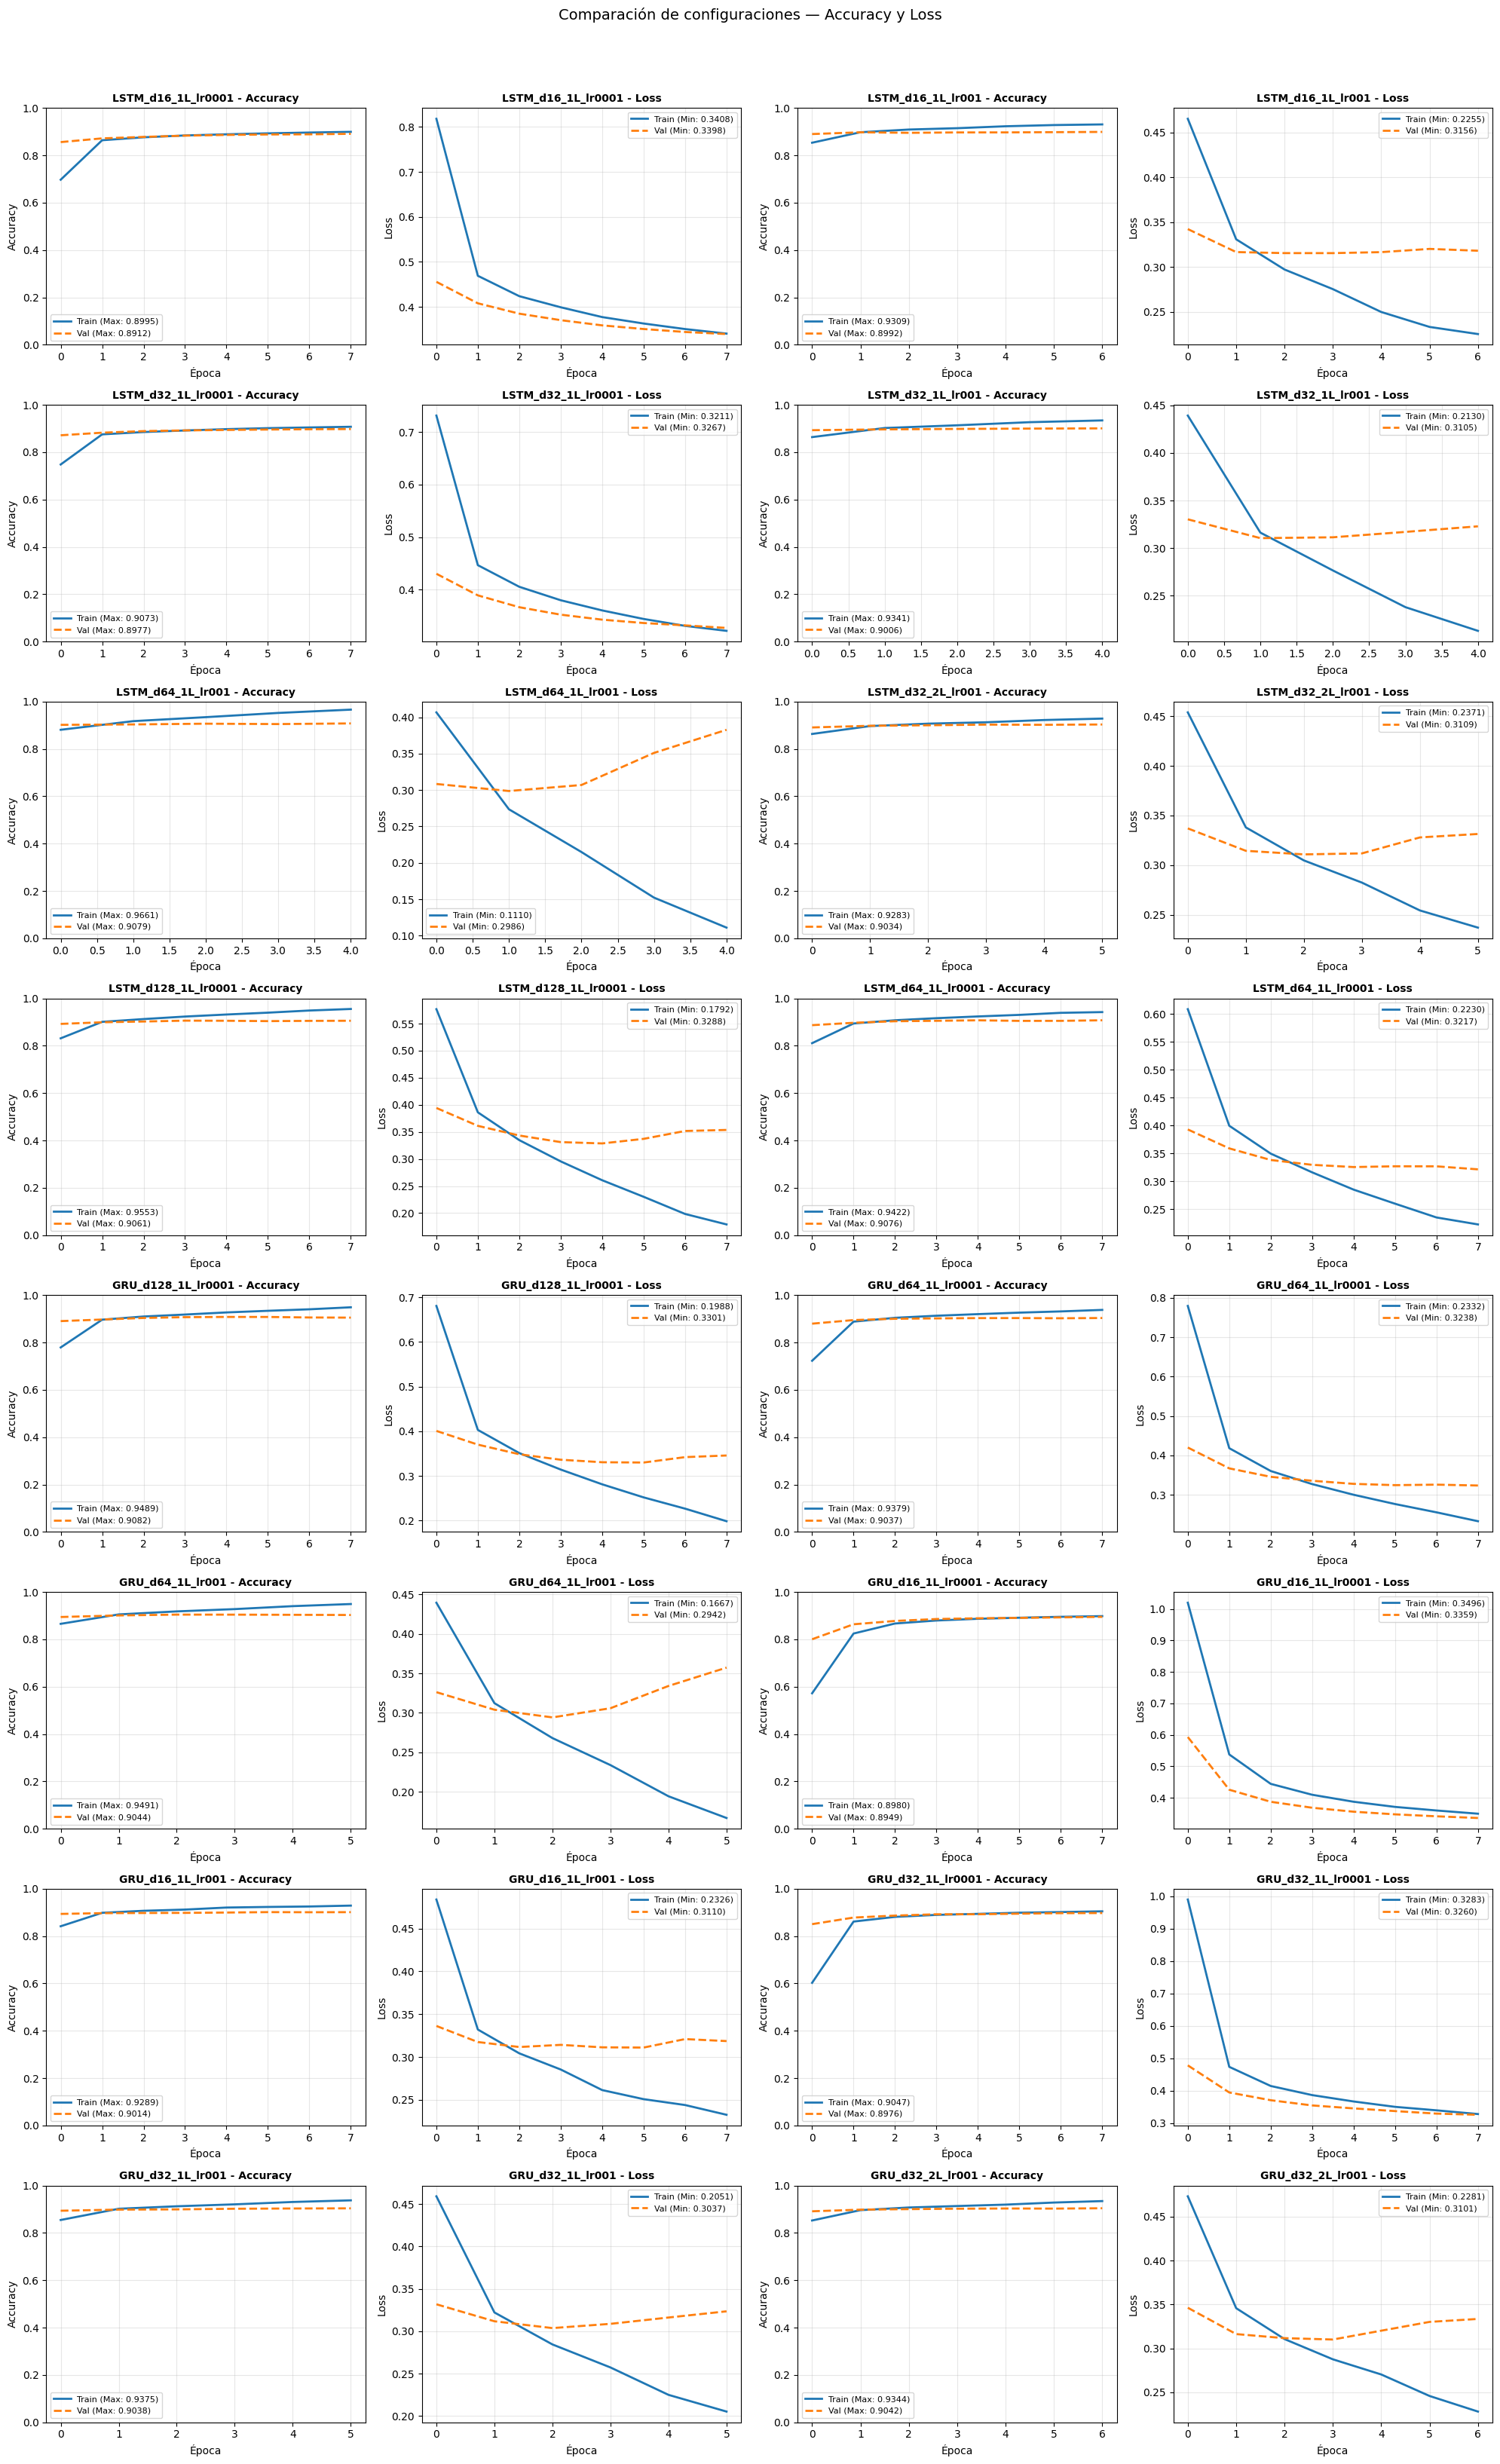

In [ ]:
def graficar_resultados_entrenamiento(resultados):
  """
  Grafica la precisión (accuracy) y pérdida (loss) de entrenamiento vs validación para cada configuración.

  Args:
      resultados (dict): Diccionario con los historiales de entrenamiento de los modelos.
  """

  n_configs = len(resultados)
  cols = 4
  rows = math.ceil(n_configs / 2)

  # Ajustar el alto de la figura dinámicamente según el número de filas
  fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
  axes = axes.flatten()

  for idx, (nombre, hist) in enumerate(resultados.items()):
      ax_acc = axes[idx * 2]
      ax_loss = axes[idx * 2 + 1]

      # Encontrar los valores máximos y mínimos
      max_acc = max(hist['accuracy'])
      max_val_acc = max(hist['val_accuracy'])
      min_loss = min(hist['loss'])
      min_val_loss = min(hist['val_loss'])

      # Dibujar las gráficas de Accuracy
      ax_acc.plot(hist['accuracy'],     label=f'Train (Max: {max_acc:.4f})', linewidth=2)
      ax_acc.plot(hist['val_accuracy'], label=f'Val (Max: {max_val_acc:.4f})',   linewidth=2, linestyle='--')
      ax_acc.set_title(f'{nombre} - Accuracy', fontsize=10, fontweight='bold')
      ax_acc.set_xlabel('Época')
      ax_acc.set_ylabel('Accuracy')
      ax_acc.set_ylim(0, 1)
      ax_acc.legend(fontsize=8)
      ax_acc.grid(alpha=0.3)

      # Dibujar las gráficas de Loss
      ax_loss.plot(hist['loss'],     label=f'Train (Min: {min_loss:.4f})', linewidth=2)
      ax_loss.plot(hist['val_loss'], label=f'Val (Min: {min_val_loss:.4f})',   linewidth=2, linestyle='--')
      ax_loss.set_title(f'{nombre} - Loss', fontsize=10, fontweight='bold')
      ax_loss.set_xlabel('Época')
      ax_loss.set_ylabel('Loss')
      ax_loss.legend(fontsize=8)
      ax_loss.grid(alpha=0.3)

  # Ocultar ejes sobrantes si la cuadrícula es mayor que el número de configuraciones x 2
  for idx in range(n_configs * 2, len(axes)):
      axes[idx].set_visible(False)

  plt.suptitle('Comparación de configuraciones — Accuracy y Loss', fontsize=14, y=1.02)
  plt.tight_layout()
  plt.show()

graficar_resultados_entrenamiento(resultados)


Podemos observar dentro de las gráficas de la evolución del *accuracy* y de la función de *loss* de cada uno de los modelos que el comportamiento general sigue una tendencia particular: los modelos que están empleando una tasa de aprendizaje más alta (por ejemplo, `lr=0.001`) tienden a un *overfitting* más pronunciado y rápido. Por ejemplo, el modelo `LSTM_d16_1L_lr001` experimentó un sobreajuste mayor con una diferencia final de *loss* (`diff_loss`) de `0.1054`, activando rápidamente los *callbacks*. En comparación, el conjunto de modelos que utilizan en sí una tasa de aprendizaje menor (`lr=0.0001`) presentan un aprendizaje mucho más estable, como se ve en el modelo `LSTM_d16_1L_lr0001` que logró un extraordinario `diff_loss` de apenas `0.0010` y un *accuracy* de validación de `0.8912`.

Por otro lado, el comportamiento de los modelos, con respecto a su función de pérdida, es tal que el conjunto de configuraciones propias de modelos más pequeños, como los que emplean `16` o `32` unidades, tienen un comportamiento evolutivo mucho más estable y convergente que el propio de modelos más grandes o con mayor cantidad de neuronas dentro de las capas recurrentes. Esto queda demostrado empíricamente al ver que los mejores modelos generales fueron arquitecturas compactas: el mejor modelo LSTM fue precisamente el de `16` unidades (`LSTM_d16_1L_lr0001` con `diff_loss=0.0010`), y el mejor modelo GRU fue el de `32` unidades (`GRU_d32_1L_lr0001` con `diff_loss=0.0023`).

Otra parte esencial de la evaluación de cada uno de los modelos es la inspección de la clasificación en particular de cada uno de los documentos dentro de los mejores modelos extraiudos de las configuraciones dadas.

De esta forma, podemos observar si existen patrones como tal dentro de la clasificación errónea del modelo, entre otras posibilidades que habilita la visualización de la matriz de confusión.


Generando matriz de confusión para: LSTM_d16_1L_lr0001
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


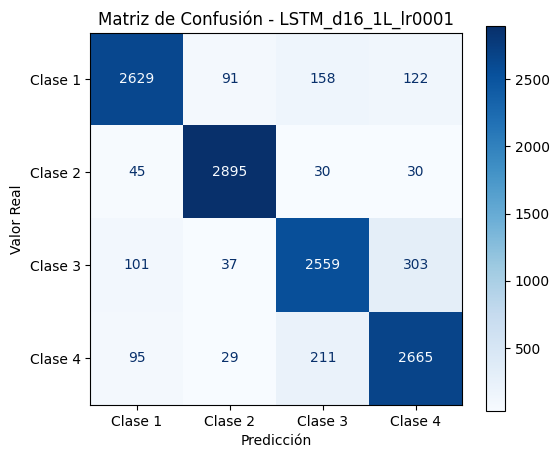


Generando matriz de confusión para: GRU_d32_1L_lr0001
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


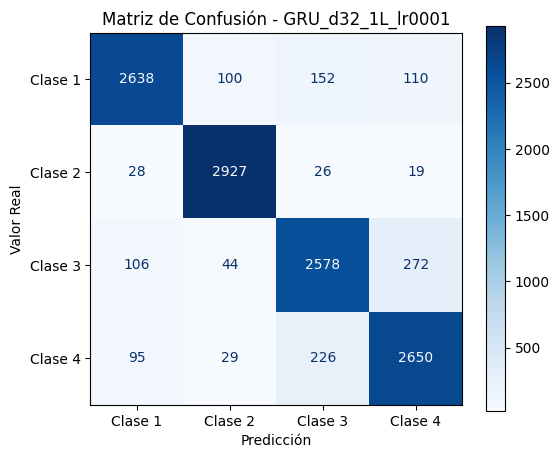

In [ ]:
def graficar_matriz_confusion(modelo, nombre, X=None, y=None):
  """
  Función que grafica la matriz de confusión de los modelos recurrentes definidos dentro
  de la práctica

  Args:
    modelo (object): el objeto del modelo entrenado
    nombre (str): nombre del modelo
    X (np.ndarray, opcional): datos de test. Por defecto usa X_te.
    y (np.ndarray, opcional): etiquetas de test. Por defecto usa y_test_raw.

  Returns:
    None
  """
  if X is None:
      X = X_te
  if y is None:
      y = y_test_raw

  if modelo is None:
      print(f"El modelo {nombre} no está definido.")
      return

  print(f"\nGenerando matriz de confusión para: {nombre}")

  y_pred_prob = modelo.predict(X)
  y_pred = np.argmax(y_pred_prob, axis=1)

  cm = confusion_matrix(y, y_pred)

  etiquetas_clases = ['Clase 1', 'Clase 2', 'Clase 3', 'Clase 4']
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas_clases)

  fig, ax = plt.subplots(figsize=(6, 5))
  disp.plot(cmap='Blues', ax=ax, values_format='d')
  plt.title(f'Matriz de Confusión - {nombre}')
  plt.xlabel('Predicción')
  plt.ylabel('Valor Real')
  plt.show()

# Graficar ambas matrices (con el test original)
graficar_matriz_confusion(mejor_lstm[0], mejor_lstm[1])
graficar_matriz_confusion(mejor_gru[0], mejor_gru[1])


Como es observable en la anteriro imagen de las matrices de confusión, ambos modelos pareen compartir un compoirtamiento sobre las predicciones realizadas bastante similar, denotando que el entrenamiento de ambos modelos, a pesar de las diferencias entre las idmensiones de las incrustaciones, el conjunto de neuronas, y otros parámetros,e s bastante sinmilar. Esto puede ser indicativo de que la naturaleza propia del corpus introduce un ligero sesgo en ciertos documenos pertenecientes a clases especificas, lo cual hace que haya una leve tendencia a la confusión entre diferentes clases dentro del corpus.

# 3. Evaluación y preguntas

## 3.1. Evaluación con corpus ajeno

Para evaluar el funcionamiento de los dos modelos extraidos como los mejores de entre todos los posibles, procuramos emplear un corpus de noticias extraídas desde diferentes fuentes ajenas al corpus de entrenamiento, con el fin de preparar una batería de pruebas con la que podamos analizar en mejor perspectiva como se comporta cada uno de los modelos que hemos escogido, tanto el que emplea arquitectura `LSTM` como el que emplea arquitectura `GRU`.

La evaluación de nuestros modelos requiere que el texto contenido dentro del corpus de evaluación tenga el mismo tratado y preprocesado realizado que el propio corpus de entrenamiento, es por ello que tras importarlo buscamos limpiar el texto de expresiones y palabras que no aporten información, asi como de signos de puntuación y edmás caracteres inservibles en el entrenamiento.

In [ ]:
test_custom_data = [
    (1, "UN Security Council Meets to Discuss Peacekeeping Efforts in Africa", "Diplomats from various nations gathered at the UN headquarters today to negotiate a new mandate for peacekeeping forces in conflict-torn regions of Africa."),
    (1, "Massive Earthquake Strikes Coastal City, Triggering Tsunami Warnings", "A magnitude 7.8 earthquake rocked the eastern seaboard early Wednesday morning, prompting authorities to issue immediate evacuation orders for coastal residents."),
    (1, "European Union Approves New Trade Tariffs", "The European parliament has passed a controversial bill imposing new tariffs on imported agricultural goods, drawing mixed reactions from member states."),
    (1, "Local Elections Yield Surprising Results in the Capital", "Opposition candidates secured a landmark victory in the mayoral race, ending a decade of dominance by the ruling party."),
    (1, "Global Climate Summit Reaches Landmark Agreement", "Leaders from over 150 countries signed a binding resolution to significantly reduce carbon emissions by the end of the decade."),
    (2, "Star Quarterback Ruled Out for the Rest of the Season", "The team's playoff hopes took a major hit after an MRI confirmed that their MVP-candidate quarterback suffered a torn ACL during Sunday's game."),
    (2, "Sensational Rookie Breaks Scoring Record in Championship Game", "The 19-year-old phenom delivered an unforgettable performance, netting 45 points to lead his team to their first national title in twenty years."),
    (2, "Heavy Rain Delays Start of the Grand Prix", "Organizers were forced to postpone the start of the highly anticipated race due to severe weather conditions that rendered the track unsafe for drivers."),
    (2, "United Secures Victory with Last-Minute Goal", "A dramatic header in stoppage time gave the home team a crucial 2-1 win over their bitter rivals in front of a sold-out stadium."),
    (2, "Legendary Tennis Champion Announces Retirement", "After an illustrious career spanning two decades and 20 Grand Slam titles, the tennis icon emotionally revealed that this season will be his last."),
    (3, "Tech Giant Reports Record Third-Quarter Profits", "Driven by surging cloud computing revenue and strong hardware sales, the multinational corporation shattered Wall Street expectations in its latest earnings call."),
    (3, "Oil Prices Tumble Amidst Fears of Global Recession", "Crude oil futures dropped by more than 5% on Monday as investors reacted to newly released economic data indicating a slowdown in manufacturing."),
    (3, "Federal Reserve Hints at Potential Interest Rate Hikes", "The central bank's chairman suggested that additional rate increases might be necessary to combat persistent inflation, sending stock markets into a brief slump."),
    (3, "Major Automakers Announce Multi-Billion Dollar Merger", "Two of the world's largest car manufacturers have officially agreed to combine their operations in a strategic move to dominate the electric vehicle market."),
    (3, "Retail Chains Struggle as E-commerce Sales Continue to Soar", "Traditional brick-and-mortar stores are facing unprecedented challenges this holiday season, reporting a significant decline in foot traffic compared to online shopping."),
    (4, "Researchers Develop Revolutionary Solid-State Battery", "A team of engineers has successfully created a new battery prototype that promises to double the range of electric vehicles while drastically reducing charging times."),
    (4, "Next-Generation Space Telescope Captures Stunning Images of Exoplanet", "The newly deployed observatory beamed back high-resolution photos of a distant planet, revealing atmospheric details never before seen by astronomers."),
    (4, "New AI Algorithm Predicts Protein Structures with Unprecedented Accuracy", "Scientists claim their latest machine learning model has solved a 50-year-old grand challenge in biology, potentially accelerating drug discovery and development."),
    (4, "Tech Startup Unveils Sleek Augmented Reality Glasses", "Promising to blend the digital and physical worlds, the lightweight AR headset was showcased at the annual tech expo, drawing widespread excitement from developers."),
    (4, "Major Cybersecurity Flaw Discovered in Popular Operating System", "Experts are urging users to download an emergency patch after a critical vulnerability was found that could allow hackers to gain full control of vulnerable devices.")
]

df_test = pd.DataFrame(test_custom_data, columns=['Class Index', 'Title', 'Description'])

df_test['Description_clean'] = df_test['Description'].apply(limpiar_texto)
df_test['Title_clean'] = df_test['Title'].apply(limpiar_texto)

df_test['Texto_completo'] = df_test['Title_clean'] + ' ' + df_test['Description_clean']

tokens_test = [tokenizar(t) for t in df_test['Texto_completo']]
tokens_test = [
    [token for token in doc if token not in stopwords]
    for doc in tokens_test
]

secuencias_test_custom = [texto_a_ids(doc, word2idx) for doc in tokens_test]

X_test_custom = pad_sequences(secuencias_test_custom, maxlen=MAX_LEN, padding='post', truncating='post')

y_test_custom_raw = df_test['Class Index'].values - 1
y_test_custom_cat = to_categorical(y_test_custom_raw, NUM_CLASSES)

print("Preprocesamiento de df_test completado.")
print(f"X_test_custom shape: {X_test_custom.shape}")
print(f"y_test_custom_cat shape: {y_test_custom_cat.shape}")

Preprocesamiento de df_test completado.
X_test_custom shape: (20, 31)
y_test_custom_cat shape: (20, 4)


Una vez hemos procesado los datos del corpus de evaluación, podemos realizar un análisis de la propia predicción de cada uno de los modelos, de forma que podamos discernir entre ambos sobre cual es mejor realizando predicciones en un potencial proceso de inferencia.

Evaluando mejores modelos con el dataset Custom:

Generando matriz de confusión para: LSTM_d16_1L_lr0001 (Custom)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


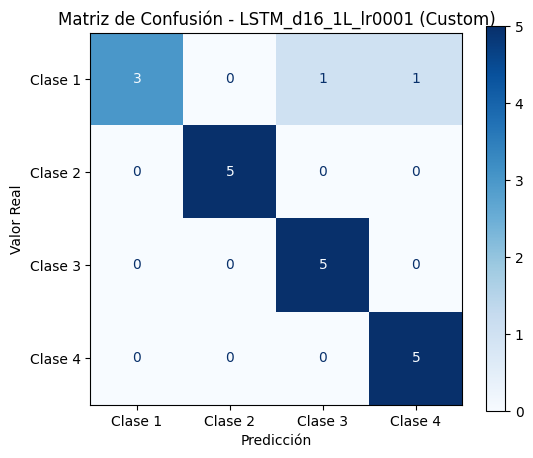


Generando matriz de confusión para: GRU_d32_1L_lr0001 (Custom)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


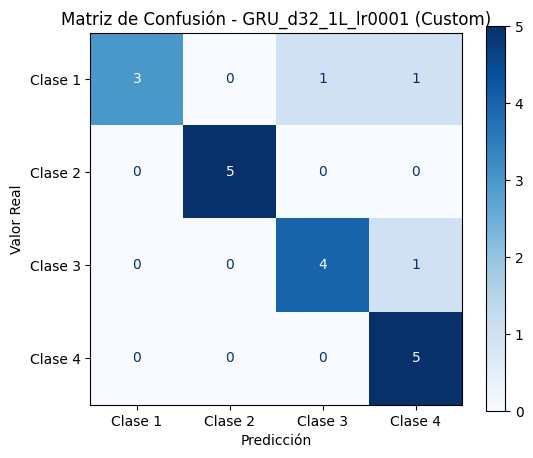

In [ ]:
print("Evaluando mejores modelos con el dataset Custom:")
graficar_matriz_confusion(mejor_lstm[0], mejor_lstm[1] + " (Custom)", X=X_test_custom, y=y_test_custom_raw)
graficar_matriz_confusion(mejor_gru[0], mejor_gru[1] + " (Custom)", X=X_test_custom, y=y_test_custom_raw)


## 3.2. Preguntas

**¿Ha alcanzado su modelo un entrenamiento óptimo? Justifique su respuesta con observaciones relevantes.**

Nuestros modelos escogidos de entre las posibles arquitcturas a usar para poder resolver el problema de clasificación de textos han tenido un entrenamieto óptimo. Esto es justificable a través de la observación de diferentes puntos sobre los que podemos basar nuestros argumentos:

* Generalización: nuestros modelos en ambas ocasiones tienen una buena generalización, dado que la diferencia entre el valor de la función de pérdida entre el entrenamiento y la validación es bastante reducido, siendo casos como el de `LSTM_d16_1L_lr0001`, el cual contiene una diferencia entre ambas métricas de tan solo 0,001. Esta indicación da a lugar que el fenómeno del *overfiting* no se de prácticamente.  
* Convergencia estable: ambos modelos seleccionados muestran un comportamiento estable a lo largo de las épocas de entrenamiento, dado que las métricas como el `val_loss` desciende de manera uniforme, sin presentar saltos bruscos o cambios notables, así como el `accuracy` también presenta una evolución consistente.

Para haber conseguido estos dos indicativos de un entrenamiento óptimo, se ha debido de emplear dentro de la arquitectura de red neuronal una regularización aplicada a diferentes capas y de diferentes formas, como lo son el uso de L2, así como el uso de capas de `Dropout`.

**¿Qué revela la matriz de confusión sobre el rendimiento de su modelo? Analice la matriz para evaluar la capacidad de generalización de su modelo.**

La matriz de confusión revela un rendimiento muy sólido y consistente de ambos modelos. Observamos una fuerte concentración de predicciones en la diagonal principal, lo que indica que la gran mayoría de las muestras han sido clasificadas correctamente. Los valores fuera de la diagonal (falsos positivos y falsos negativos) son relativamente bajos y simétricos, indicando que el modelo no está excesivamente sesgado hacia una clase en particular. Podemos observar que si se presenta una ligera tendencia a la confusión entre las clases 1, 3 y 4, teniendo la clase 2 una menor tasa de fallo en su predicción.

En cuanto a su capacidad de generalización, el comportamiento de la matriz de confusión sobre los datos de test, así como en el corpus extraído de manera independiente (custom), corrobora que el modelo ha aprendido características semánticas subyacentes útiles y no simplemente memorizado los datos. Las ligeras confusiones que presenta suelen estar justificadas por el solapamiento natural del vocabulario entre temáticas afines (por ejemplo, noticias empresariales vs tecnología).

**¿Qué diferencia en la precisión final observó al cambiar de una representación de incrustación a otra?**

Al comparar el rendimiento entre las incrustaciones de menor dimensión (`dim312_v2`) y las de mayor dimensión (`dim752_v3`), se observa que el aumento de dimensionalidad no supuso una mejora significativa y estable en la precisión de validación, sino que más bien incrementó la tendencia al sobreajuste (*overfitting*). De hecho, los modelos que lograron la mejor relación entre *accuracy* y menor diferencia de pérdidas (`diff_loss`) fueron aquellos entrenados con los *embeddings* más compactos (`dim312_v2`). Esto se debe a que una mayor cantidad de dimensiones introduce una cantidad mucho mayor de parámetros en el modelo, lo que facilita que la red memorice ruido o características muy específicas del conjunto de entrenamiento en lugar de aprender representaciones lingüísticas generalizables a datos no vistos.

**¿La arquitectura LSTM/GRU reaccionó de forma diferente a los dos tipos de incrustación?**

En términos generales, ambas arquitecturas (LSTM y GRU) reaccionaron de forma muy similar a los dos tipos de incrustación. Ninguna de las dos obtuvo un beneficio claro de utilizar los *embeddings* de mayor dimensionalidad (`dim752_v3`). Por el contrario, tanto LSTM como GRU sufrieron un mayor sobreajuste al emplear las incrustaciones de 752 dimensiones, debido al drástico aumento en la cantidad de parámetros a entrenar. Como resultado, los modelos más óptimos y estables para ambas arquitecturas se obtuvieron utilizando las incrustaciones de menor dimensión (`dim312_v2`), demostrando que, para este corpus y problema específico, una representación más compacta es preferible independientemente del tipo de celda recurrente utilizada.